In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/addiction_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
df.describe()


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


### Most Numeric Data have Uniform Distribution. Quantile Transformer Transforms them to Normal Distribution

### Age is multimodal. I won't apply Quantile Transformer because the modes have meaning. (Age groups)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'social_media_hours'}>],
       [<Axes: title={'center': 'gaming_hours'}>,
        <Axes: title={'center': 'work_study_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'notifications_per_day'}>,
        <Axes: title={'center': 'app_opens_per_day'}>,
        <Axes: title={'center': 'weekend_screen_time'}>],
       [<Axes: title={'center': 'addicted_label'}>, <Axes: >, <Axes: >]],
      dtype=object)

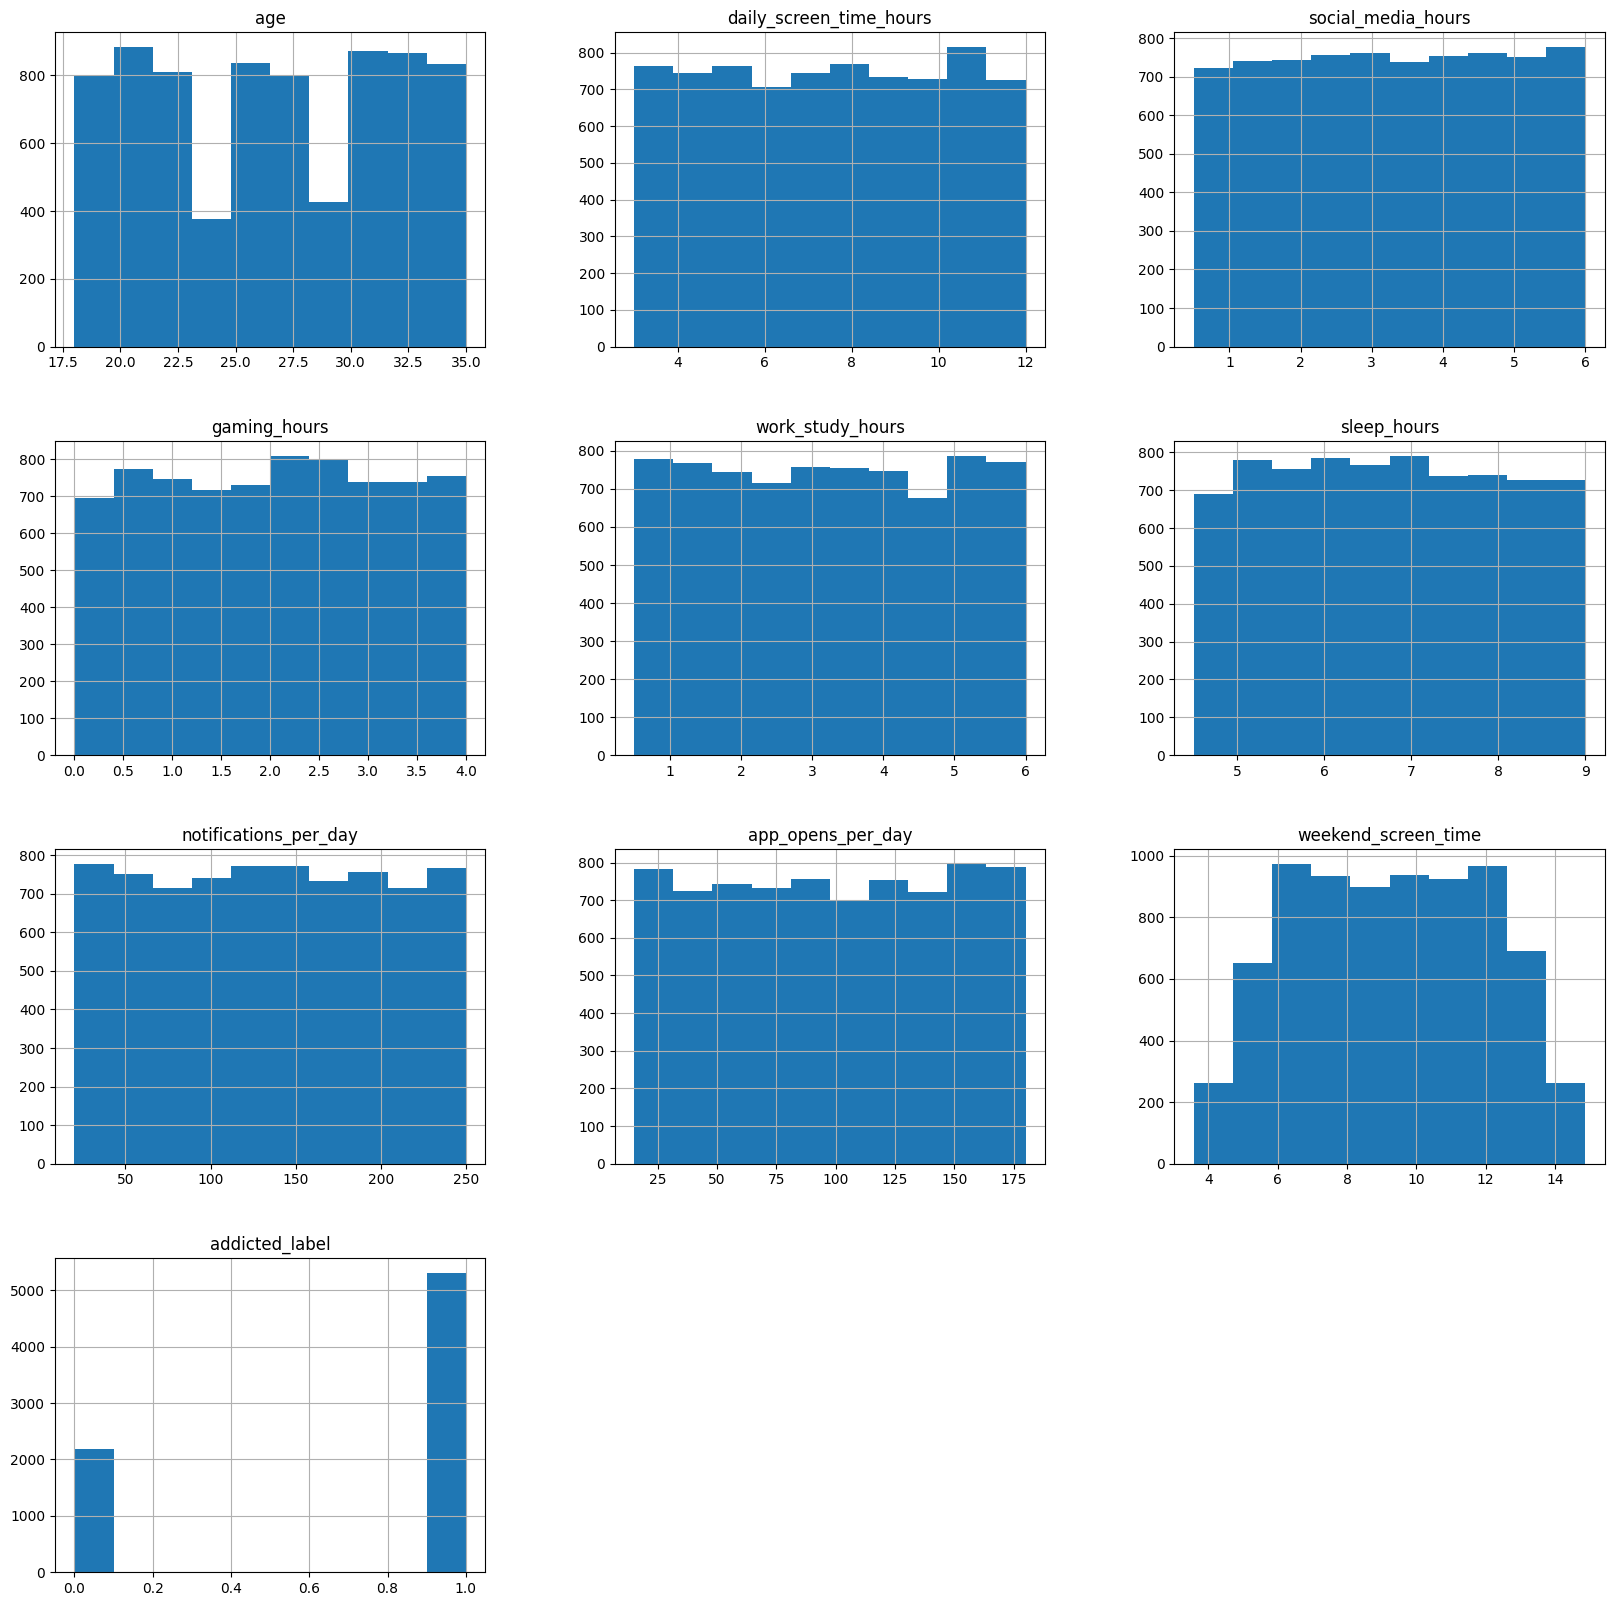

In [5]:
df.hist(figsize=(20,20))

<Axes: xlabel='addiction_level', ylabel='count'>

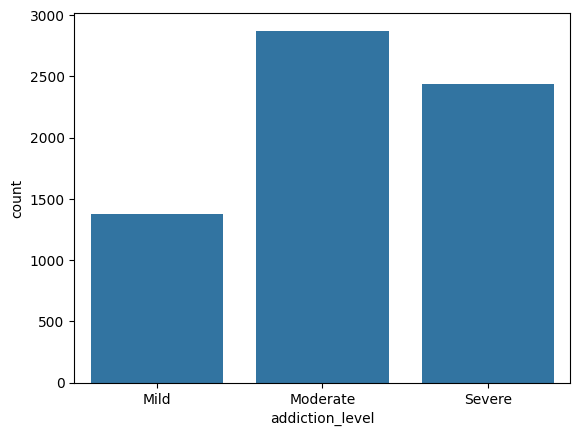

In [6]:
sns.countplot(data=df,x='addiction_level')

<Axes: xlabel='addiction_level', ylabel='weekend_screen_time'>

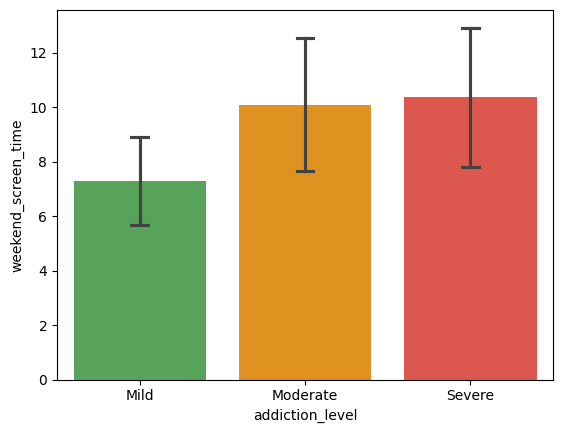

In [7]:

palette = {"Mild": "#4CAF50", "Moderate": "#FF9800", "Severe": "#F44336"}  # update keys to match your actual category names

sns.barplot(
    data=df,
    x="addiction_level",
    y="weekend_screen_time",
    hue="addiction_level",
    palette=palette,
    errorbar="sd",      
    capsize=0.1,
    legend=False
)

<Axes: xlabel='gender', ylabel='count'>

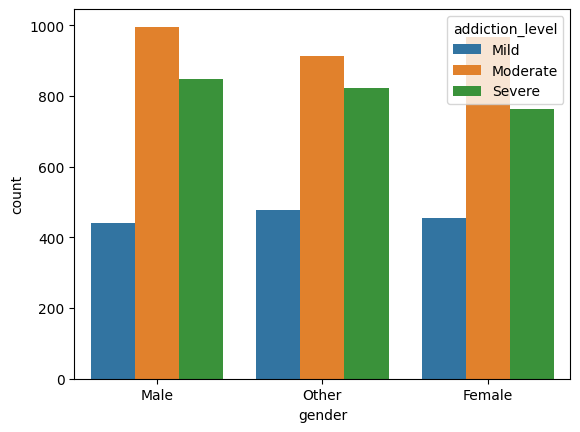

In [10]:
sns.countplot(data = df, x='gender', hue = 'addiction_level')

<Axes: xlabel='academic_work_impact', ylabel='count'>

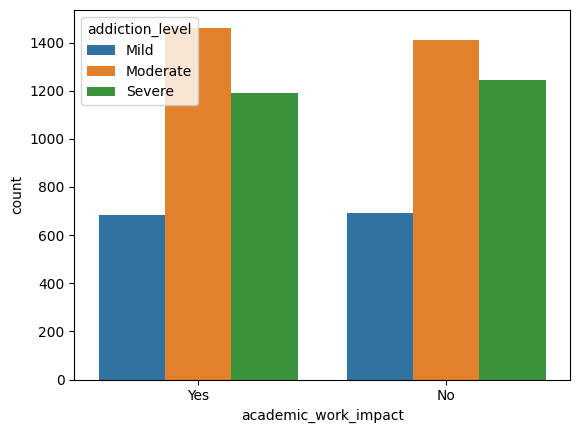

In [11]:
sns.countplot(data = df, x='academic_work_impact', hue = 'addiction_level')

In [ ]:
numeric_df = df.select_dtypes(include="number")

In [ ]:
corr = numeric_df.corr()

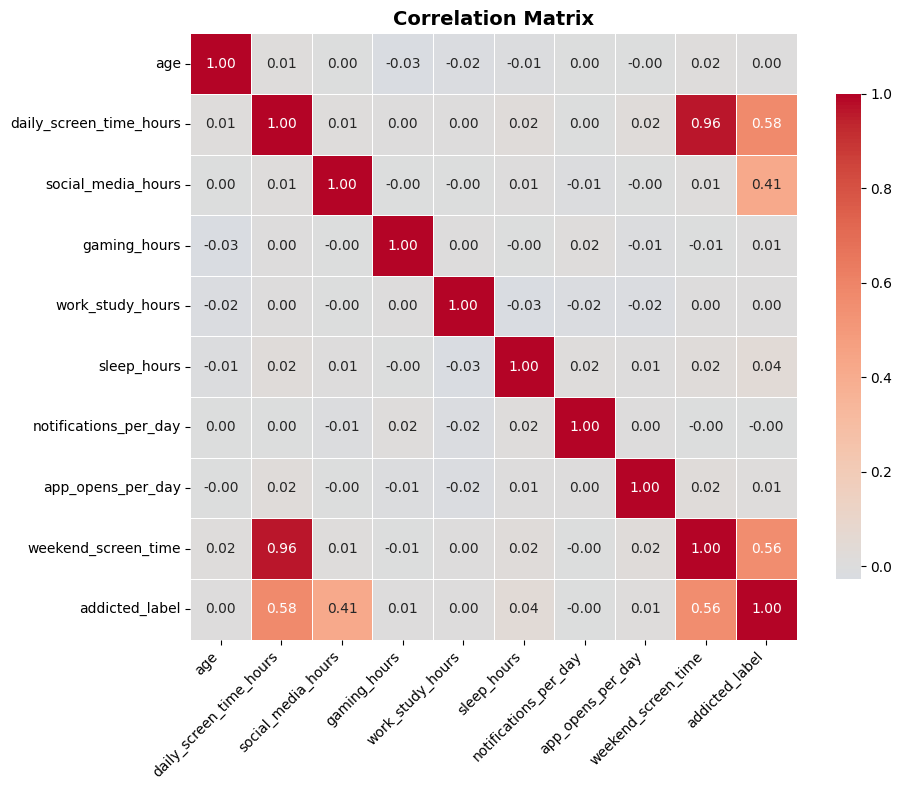

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Axes: >

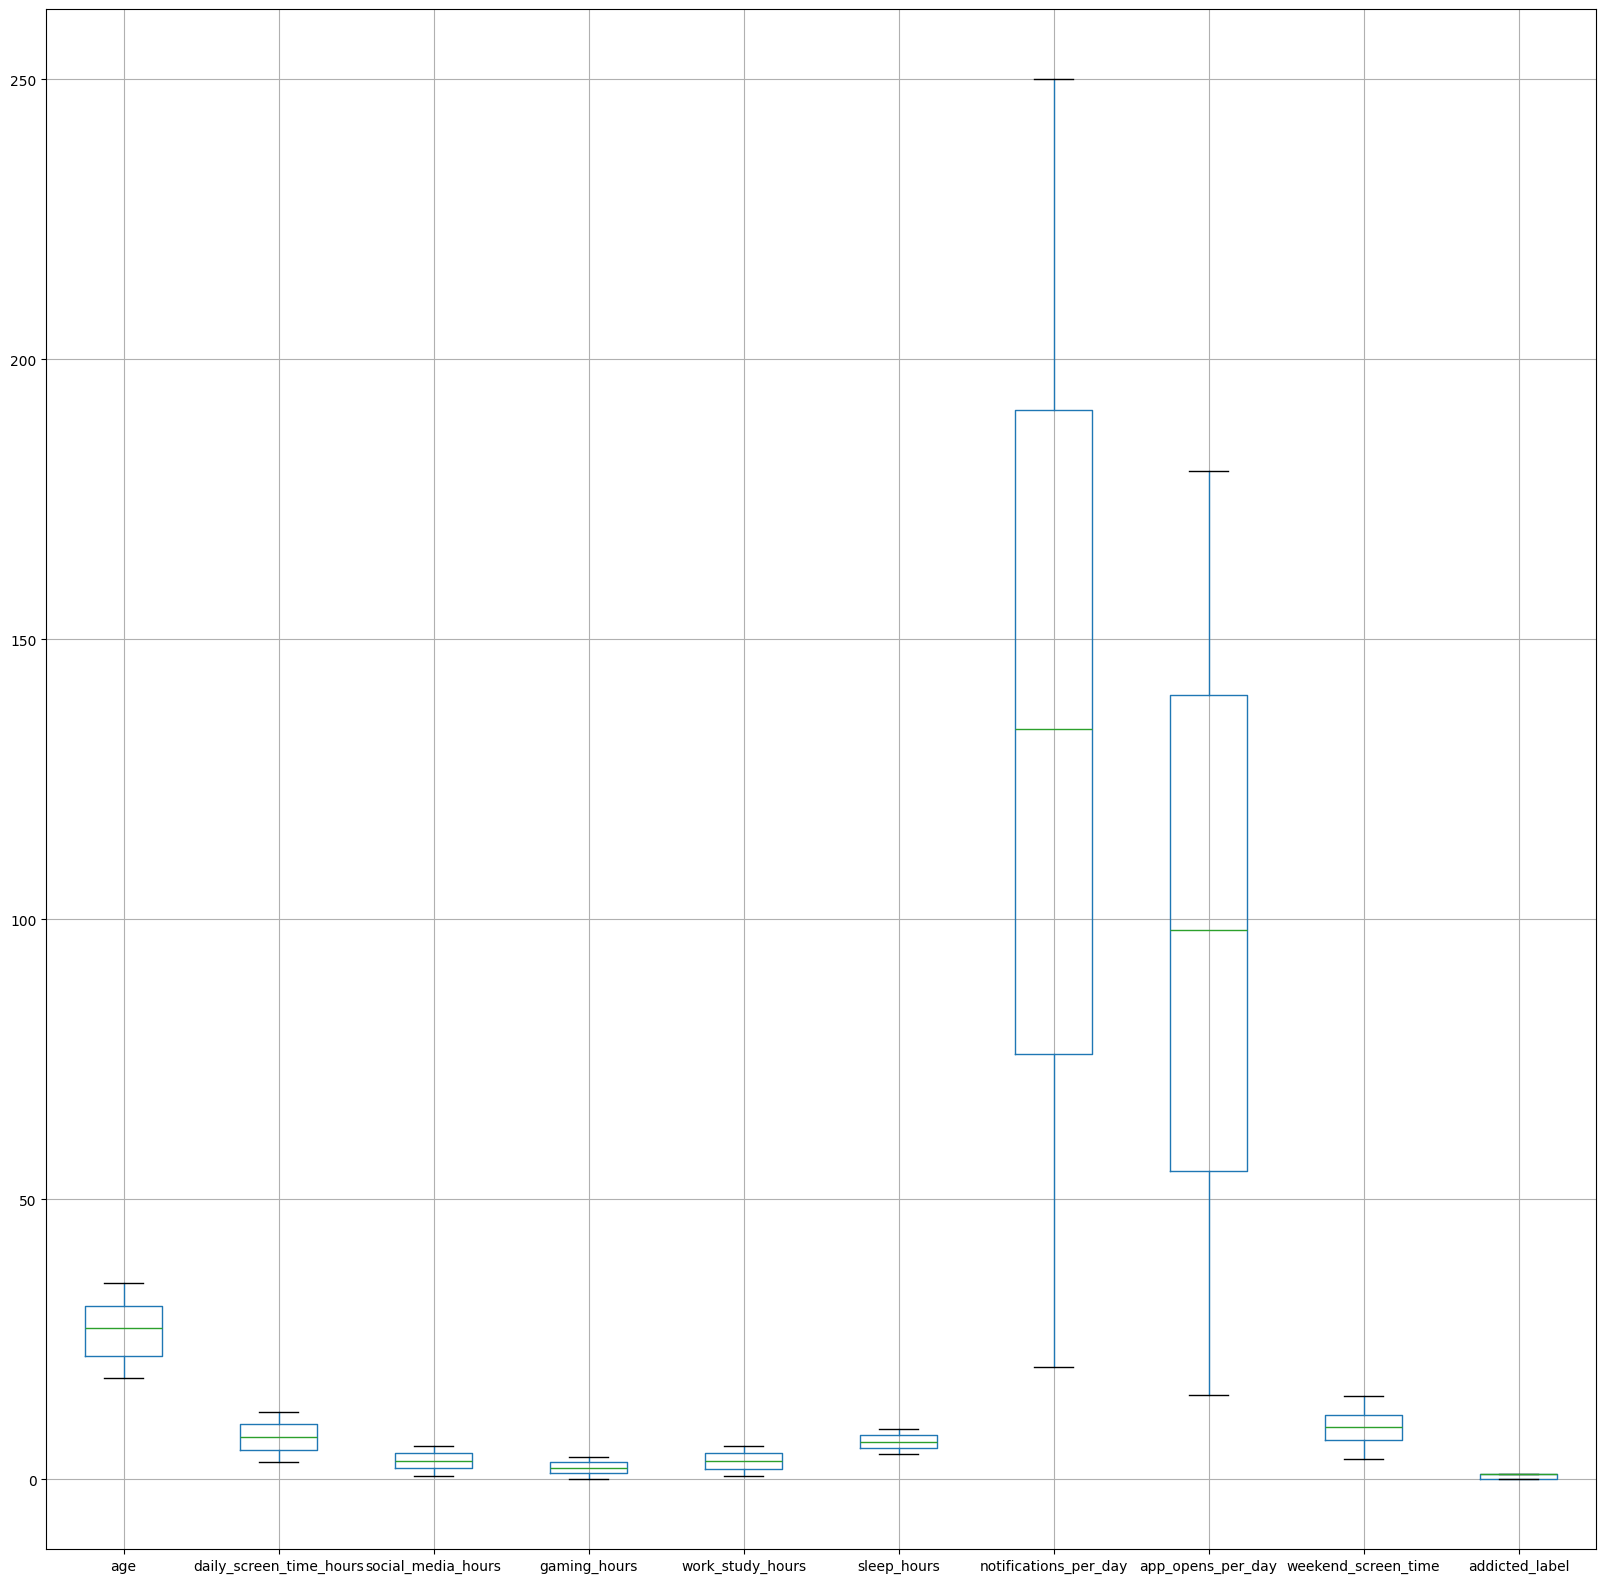

In [ ]:
df.boxplot(figsize=(20,20))